# Exploratory Data Analysis
EDA on `imputed_tbl` and `nonimputed_tbl` from the endgbv RDS database.

## Setup

In [1]:
import os
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from dotenv import load_dotenv
from sqlalchemy import create_engine

In [2]:
load_dotenv()
user = 'hw566'
pw   = os.environ.get('Password')

engine = create_engine(
    f'postgresql://{user}:{pw}'
    '@endgbv-database.cx62ou6gkd87.us-east-2.rds.amazonaws.com:5432/postgres?sslmode=require'
)

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

## Load Data

In [3]:
impute_copy = pd.read_sql('SELECT * FROM imputed_tbl', engine)
raw_copy    = pd.read_sql('SELECT * FROM nonimputed_tbl', engine)

print('impute_copy:', impute_copy.shape)
print('raw_copy:   ', raw_copy.shape)

impute_copy: (483790, 15)
raw_copy:    (483790, 15)


## 1. Overview

In [4]:
impute_copy.head()

,Offense Type,Report Date,Incident Precinct Code,Borough Name,COMMDIST,Unemployment,Median Income,Poverty,Intimate Relationship Flag,Victim Race,Victim Sex,Suspect Race,Suspect Sex,after_reopening,month_year
0,DIR,12/31/2021,40,BRONX,201.0,Yes,Yes,Yes,Yes,WHITE,FEMALE,WHITE,MALE,Yes,2021-12
1,DIR,12/31/2021,40,BRONX,201.0,Yes,Yes,Yes,Yes,BLACK,FEMALE,BLACK,MALE,Yes,2021-12
2,DIR,12/31/2021,40,BRONX,201.0,Yes,Yes,Yes,No,BLACK,FEMALE,BLACK,MALE,Yes,2021-12
3,DIR,12/31/2021,40,BRONX,201.0,Yes,Yes,Yes,Yes,BLACK,FEMALE,BLACK,MALE,Yes,2021-12
4,DIR,12/31/2021,40,BRONX,201.0,Yes,Yes,Yes,No,BLACK,FEMALE,BLACK,FEMALE,Yes,2021-12


In [5]:
impute_copy.dtypes

Offense Type                   object
Report Date                    object
Incident Precinct Code          int64
Borough Name                   object
COMMDIST                      float64
Unemployment                   object
Median Income                  object
Poverty                        object
Intimate Relationship Flag     object
Victim Race                    object
Victim Sex                     object
Suspect Race                   object
Suspect Sex                    object
after_reopening                object
month_year                     object
dtype: object

In [6]:
print(impute_copy['Unemployment'].unique()[:20])
print(impute_copy['Median Income'].unique()[:20])
print(impute_copy['Poverty'].unique()[:20])

['Yes' 'No']
['Yes' 'No']
['Yes' 'No']


## 2. Missingness (raw_copy)

In [7]:
def pct_unknown(series):
    """
    For a given column, calculate the proportion of rows that were originally
    missing — identified by the placeholder string 'unknown_<column_name>'
    that was used during data cleaning to fill nulls.
    
    E.g. for a column called 'Race Ethnicity', the fill value would be
    'unknown_race_ethnicity'.
    """
    fill_val = f"unknown_{series.name.replace(' ', '_')}".lower()
    return (series == fill_val).mean()  # .mean() on a boolean series = proportion of True values

In [8]:
# Apply to every column in raw_copy, sort so worst offenders appear first
miss = raw_copy.apply(pct_unknown).sort_values(ascending=False).reset_index()
miss.columns = ['column', 'pct_missing']

# Add a human-readable percentage column for display
miss['pct_missing_pct'] = (miss['pct_missing'] * 100).round(2)

C:\Users\19728\AppData\Local\Temp\ipykernel_36816\576755616.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


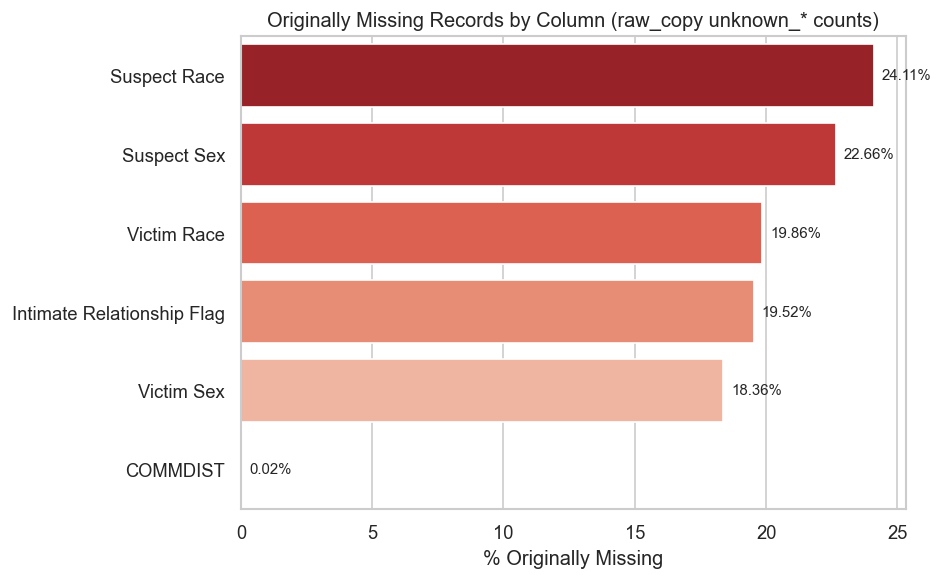

In [9]:
# Plot 
fig, ax = plt.subplots(figsize=(8, 5))

# Only plot columns that actually had missing values
sns.barplot(
    data=miss[miss['pct_missing'] > 0],
    x='pct_missing_pct',
    y='column',
    ax=ax,
    palette='Reds_r'  # darker red = higher missingness
)

ax.set_xlabel('% Originally Missing')
ax.set_ylabel('')
ax.set_title('Originally Missing Records by Column (raw_copy unknown_* counts)')

# Annotate each bar with its exact percentage value
for bar, val in zip(ax.patches, miss[miss['pct_missing'] > 0]['pct_missing_pct']):
    ax.text(
        bar.get_width() + 0.3,       # slightly right of bar end
        bar.get_y() + bar.get_height()/2,  # vertically centered on bar
        f'{val}%',
        va='center',
        fontsize=9
    ) 

plt.tight_layout()
plt.show()

In [10]:
miss

,column,pct_missing,pct_missing_pct
0,Suspect Race,0.241076,24.11
1,Suspect Sex,0.226586,22.66
2,Victim Race,0.198551,19.86
3,Intimate Relationship Flag,0.195209,19.52
4,Victim Sex,0.183557,18.36
5,COMMDIST,0.000215,0.02
6,Report Date,0.000000,0.00
7,Median Income,0.000000,0.00
8,Unemployment,0.000000,0.00
9,Borough Name,0.000000,0.00


## 3. Incident Volume Over Time

In [11]:
# Work on a copy 
ts = impute_copy.copy()

# Convert month_year from string to datetime so it plots correctly on the x-axis
ts['month_year'] = pd.to_datetime(ts['month_year'])

# Count the number of incidents per month
monthly = ts.groupby('month_year').size().reset_index(name='n_incidents')

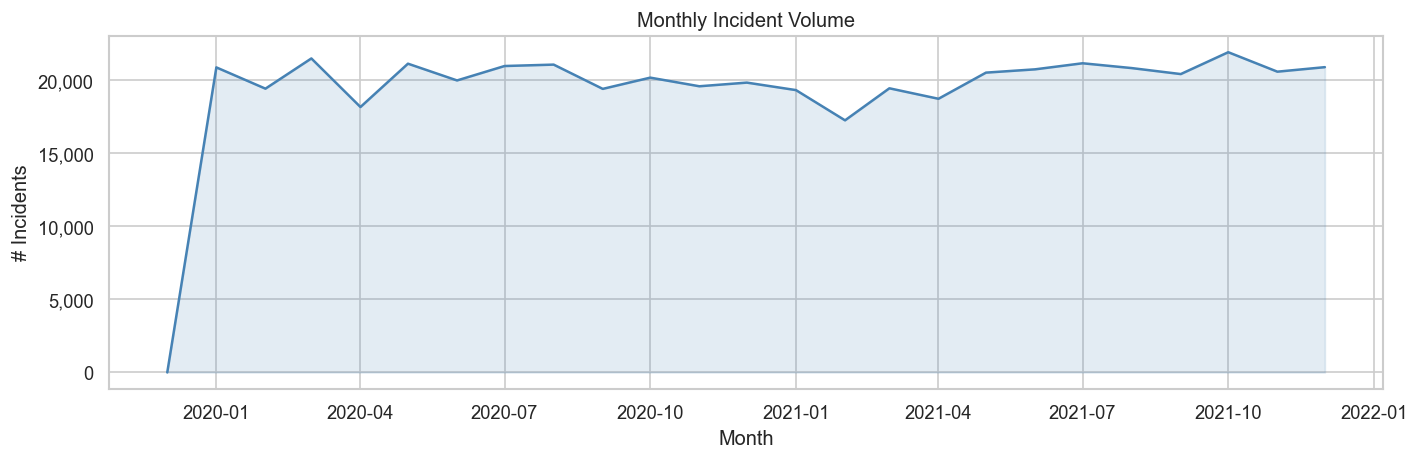

In [12]:
# Plot 
fig, ax = plt.subplots(figsize=(12, 4))

# Line plot of monthly incident counts
ax.plot(monthly['month_year'], monthly['n_incidents'], linewidth=1.5, color='steelblue')

# Shaded area under the line for easier volume reading
ax.fill_between(monthly['month_year'], monthly['n_incidents'], alpha=0.15, color='steelblue')

ax.set_title('Monthly Incident Volume')
ax.set_xlabel('Month')
ax.set_ylabel('# Incidents')

# Format y-axis with commas (e.g. 10,000 instead of 10000)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.show()

## 4. Before vs After Reopening

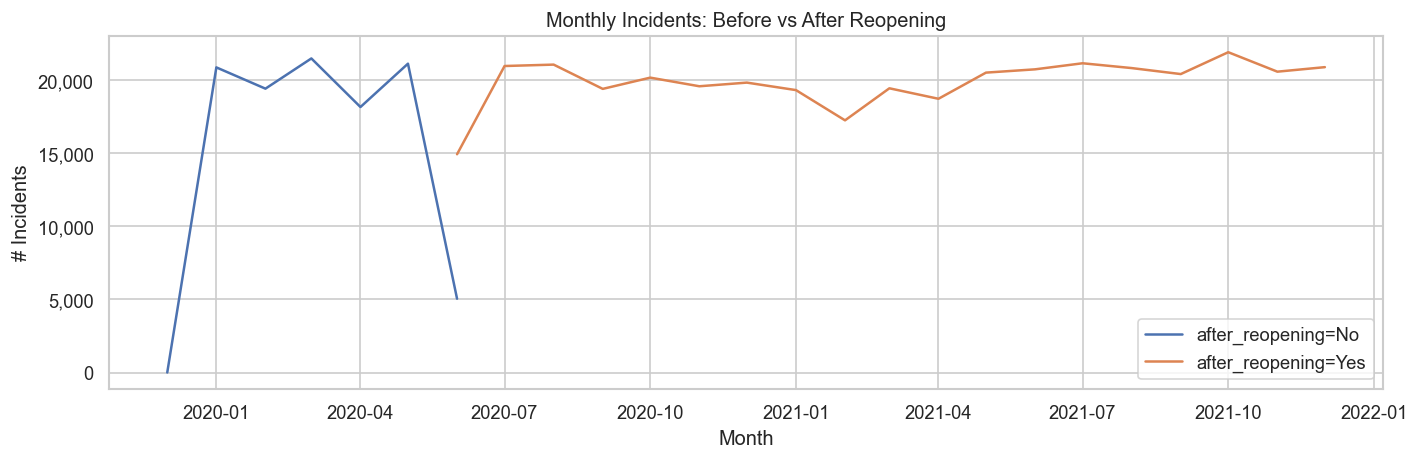

In [13]:
# Count incidents per month split by the after_reopening flag
reopen_counts = impute_copy.groupby(['month_year', 'after_reopening']).size().reset_index(name='n')
reopen_counts['month_year'] = pd.to_datetime(reopen_counts['month_year'])

fig, ax = plt.subplots(figsize=(12, 4))

# Plot a separate line for each value of after_reopening (0 = before, 1 = after)
for label, grp in reopen_counts.groupby('after_reopening'):
    ax.plot(grp['month_year'], grp['n'], label=f'after_reopening={label}', linewidth=1.5)

ax.set_title('Monthly Incidents: Before vs After Reopening')
ax.set_xlabel('Month')
ax.set_ylabel('# Incidents')
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

## 5. Offense Type Distribution

In [14]:
# Count how often each offense type appears in the imputed dataset
offense_counts = impute_copy['Offense Type'].value_counts().reset_index()
offense_counts.columns = ['Offense Type', 'count']

C:\Users\19728\AppData\Local\Temp\ipykernel_36816\2069925925.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=offense_counts, x='count', y='Offense Type', palette='Blues_r', ax=ax)


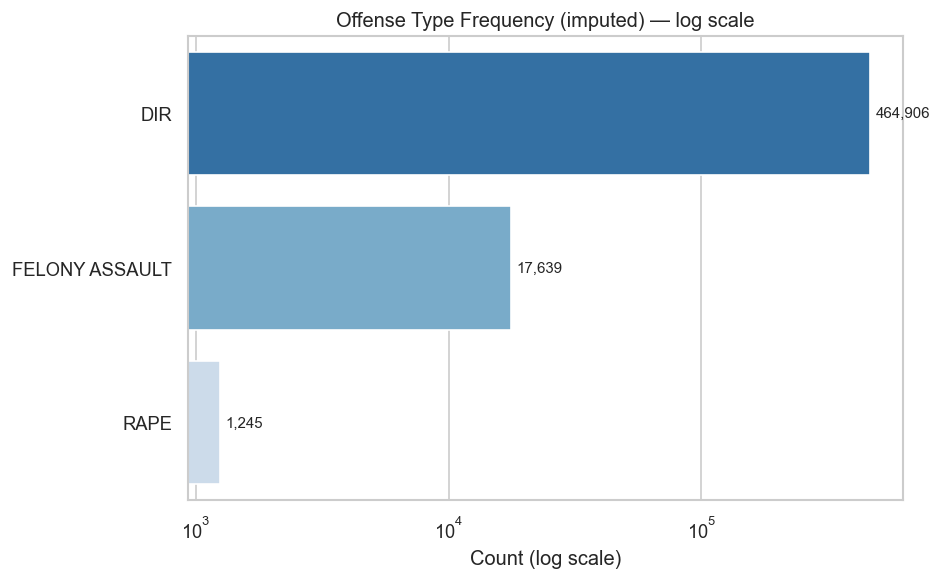

In [15]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=offense_counts, x='count', y='Offense Type', palette='Blues_r', ax=ax)

# Log scale so small categories like rape are still visible
ax.set_xscale('log')

ax.set_title('Offense Type Frequency (imputed) — log scale')
ax.set_xlabel('Count (log scale)')
ax.set_ylabel('')

# Annotate each bar with the real count
for bar, val in zip(ax.patches, offense_counts['count']):
    ax.text(bar.get_width() * 1.05, bar.get_y() + bar.get_height()/2,
            f'{int(val):,}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

## 6. Borough Distribution

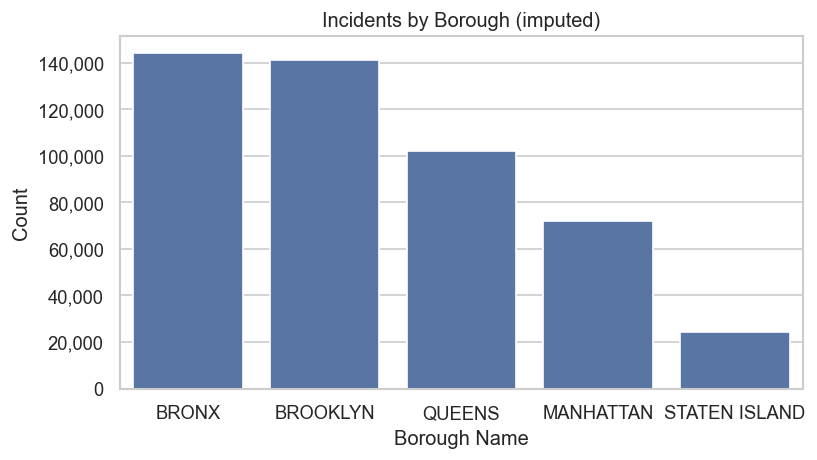

In [16]:
borough_counts = impute_copy['Borough Name'].value_counts().reset_index()
borough_counts.columns = ['Borough Name', 'count']

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=borough_counts, x='Borough Name', y='count', ax=ax)
ax.set_title('Incidents by Borough (imputed)')
ax.set_ylabel('Count')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

## 7. Categorical Variables — Imputed vs Raw Comparison

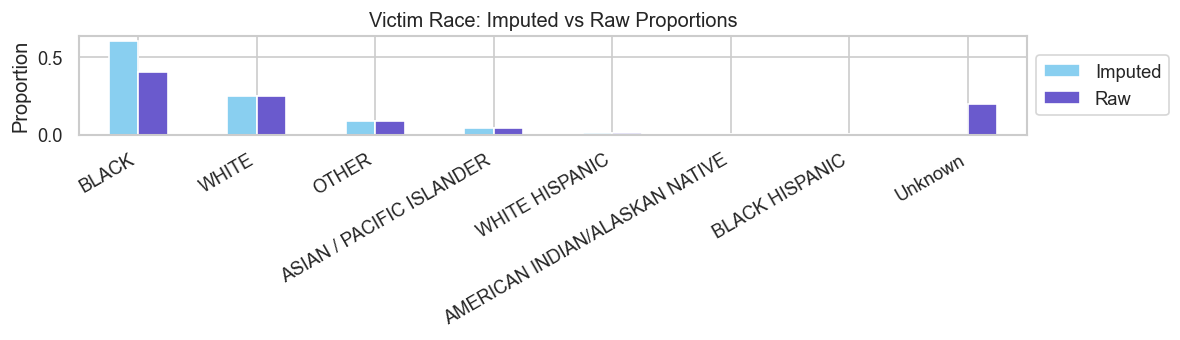

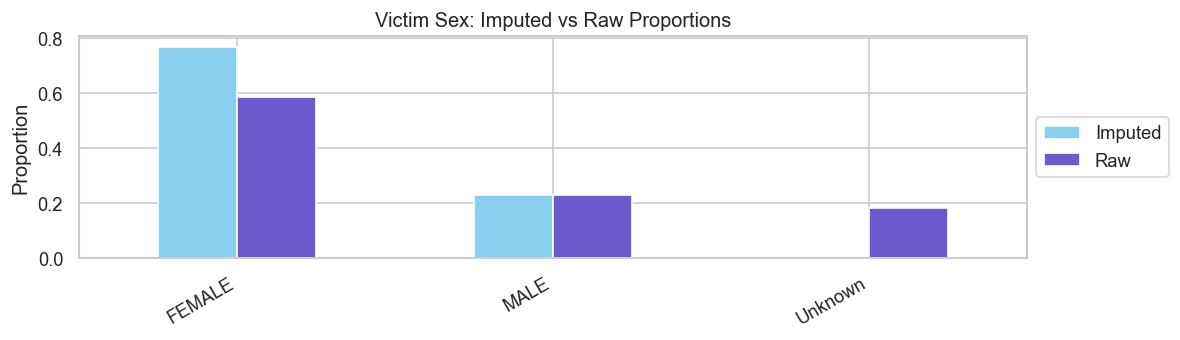

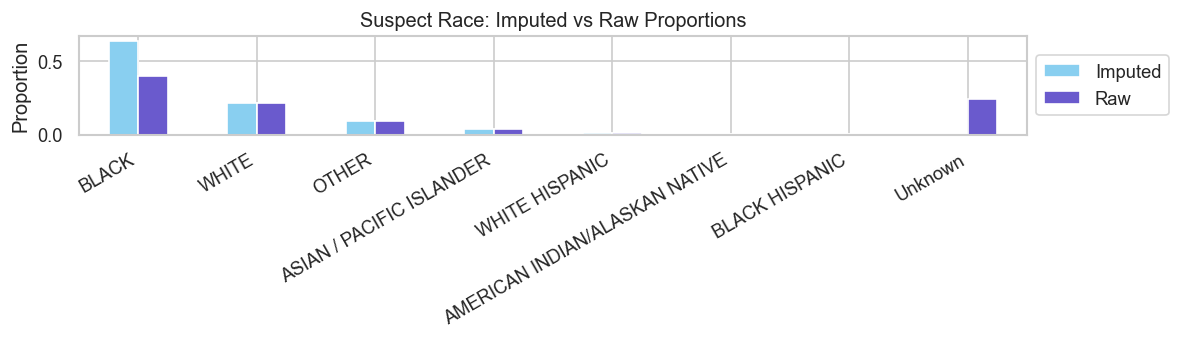

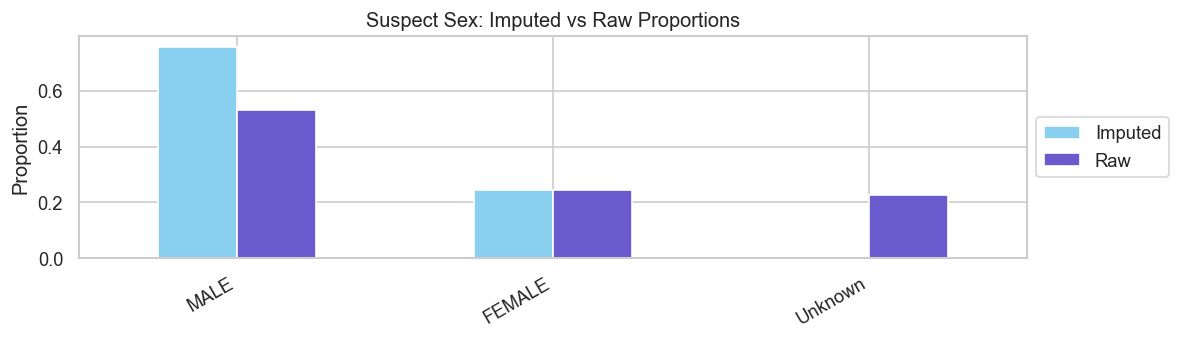

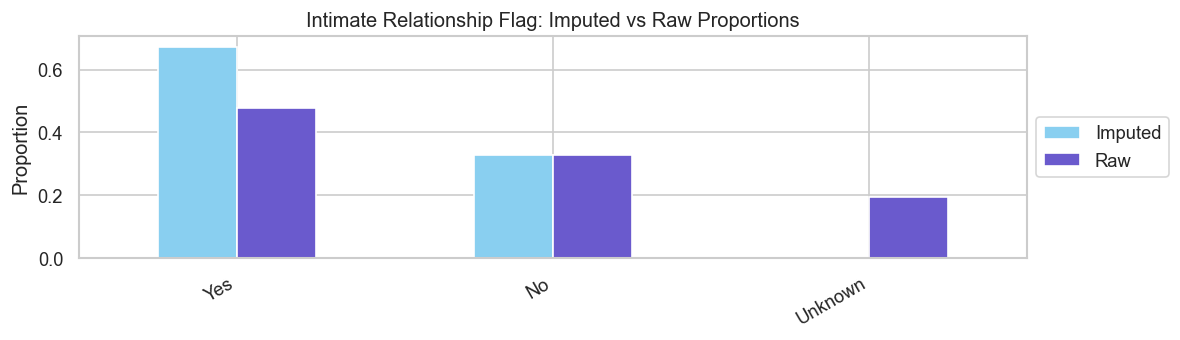

In [17]:
cat_cols = ['Victim Race', 'Victim Sex', 'Suspect Race', 'Suspect Sex', 'Intimate Relationship Flag']

for col in cat_cols:
    imp_vc = impute_copy[col].value_counts(normalize=True).rename('Imputed')
    # unknown_* values are kept as-is — they will appear as their own bar
    raw_vc = raw_copy[col].value_counts(normalize=True).rename('Raw')
    combined = pd.concat([imp_vc, raw_vc], axis=1).fillna(0).sort_values('Imputed', ascending=False)
    
    # Rename any unknown_* placeholder category to 'Unknown' for cleaner labels
    combined.index = [re.sub(r'^unknown_.*', 'Unknown', str(i)) for i in combined.index]
    
    ax = combined.plot(kind='bar', figsize=(10, 3), color=['#89CFF0', '#6A5ACD'])
    plt.title(f'{col}: Imputed vs Raw Proportions')
    plt.ylabel('Proportion')
    plt.xticks(rotation=30, ha='right')
    
    # Force legend to always appear outside the plot on the right
    ax.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), frameon=True)
    
    plt.tight_layout()
    plt.show()

## 8. Socioeconomic Covariates

In [20]:
# Encode socioeconomic columns for analysis
socio_encoded = impute_copy[['Unemployment', 'Median Income', 'Poverty', 'COMMDIST']].copy()

# Encode Yes/No as 1/0
for col in ['Unemployment', 'Median Income', 'Poverty']:
    socio_encoded[col] = socio_encoded[col].map({'Yes': 1, 'No': 0})

socio_encoded['COMMDIST'] = pd.to_numeric(socio_encoded['COMMDIST'], errors='coerce')

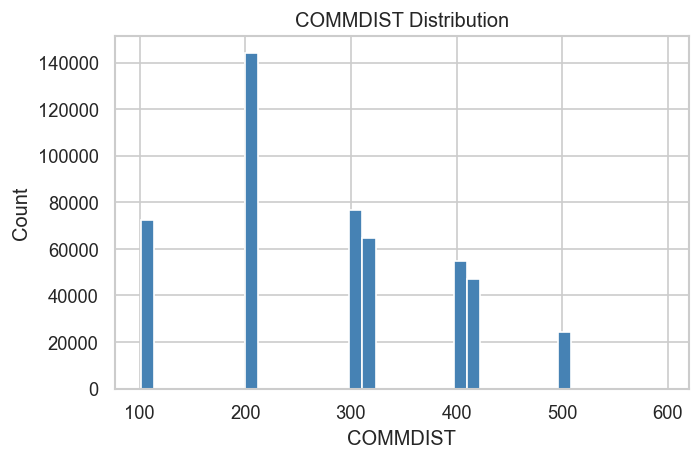

In [21]:
# COMMDIST Histogram
fig, ax = plt.subplots(figsize=(6, 4))

socio_encoded['COMMDIST'].hist(bins=40, ax=ax, color='steelblue', edgecolor='white')
ax.set_title('COMMDIST Distribution')
ax.set_ylabel('Count')
ax.set_xlabel('COMMDIST')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.tight_layout()
plt.show()

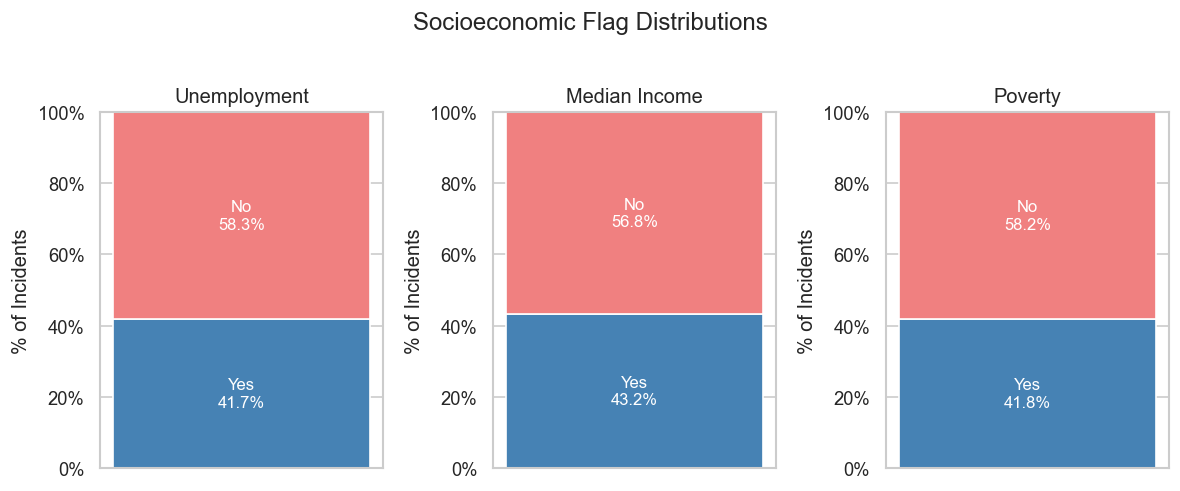

In [22]:
# Stacked Bar Charts
flag_cols = ['Unemployment', 'Median Income', 'Poverty']

fig, axes = plt.subplots(1, 3, figsize=(10, 4))

for ax, col in zip(axes, flag_cols):
    # Get Yes/No as percentages
    counts = impute_copy[col].value_counts(normalize=True) * 100

    # Stack Yes on the bottom, No on top to form a single 100% bar
    ax.bar(col, counts.get('Yes', 0), color='steelblue', label='Yes')
    ax.bar(col, counts.get('No', 0), bottom=counts.get('Yes', 0), color='lightcoral', label='No')

    ax.set_title(col)
    ax.set_ylabel('% of Incidents')
    ax.set_ylim(0, 100)
    ax.set_xticks([])  # hide the x tick label since title already names the column
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))

    # Annotate Yes percentage in the center of the Yes segment
    ax.text(col, counts.get('Yes', 0) / 2,
            f"Yes\n{counts.get('Yes', 0):.1f}%",
            ha='center', va='center', color='white', fontsize=10)

    # Annotate No percentage in the center of the No segment
    ax.text(col, counts.get('Yes', 0) + counts.get('No', 0) / 2,
            f"No\n{counts.get('No', 0):.1f}%",
            ha='center', va='center', color='white', fontsize=10)

plt.suptitle('Socioeconomic Flag Distributions', y=1.02)
plt.tight_layout()
plt.show()

## 9. Correlation Among Socioeconomic Covariates

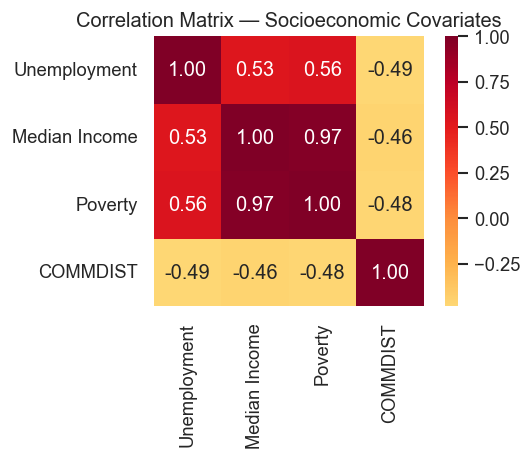

In [23]:
# Check for multicollinearity between socioeconomic covariates
socio_encoded = impute_copy[['Unemployment', 'Median Income', 'Poverty', 'COMMDIST']].copy()

# Encode Yes/No as 1/0
for col in ['Unemployment', 'Median Income', 'Poverty']:
    socio_encoded[col] = socio_encoded[col].map({'Yes': 1, 'No': 0})

socio_encoded['COMMDIST'] = pd.to_numeric(socio_encoded['COMMDIST'], errors='coerce')

corr = socio_encoded.corr()

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='YlOrRd', center=0, ax=ax, square=True)
ax.set_title('Correlation Matrix — Socioeconomic Covariates')
plt.tight_layout()
plt.show()

## 10. Incidents by Borough × Offense Type (Heatmap)

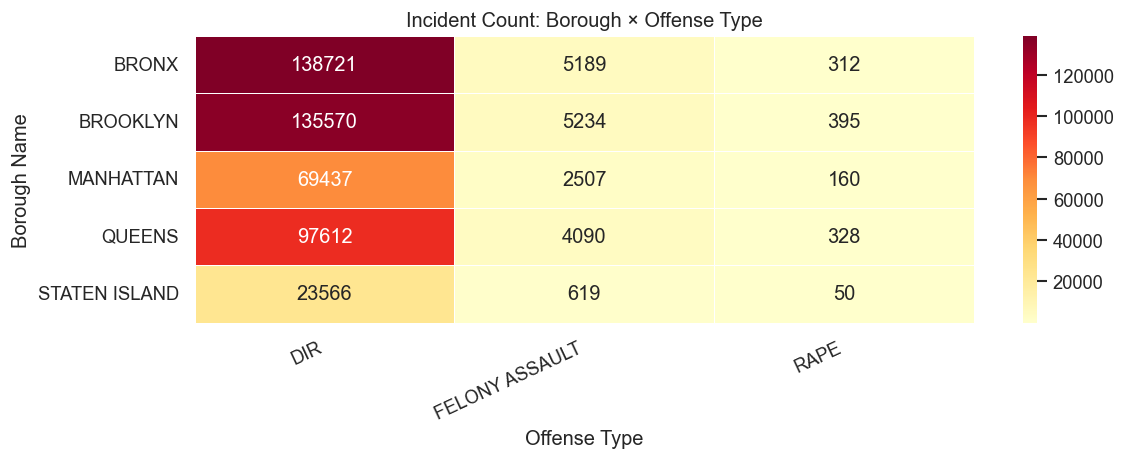

In [24]:
# Build a cross-tab of incident counts by borough and offense type
pivot = (
    impute_copy
    .groupby(['Borough Name', 'Offense Type'])
    .size()
    .reset_index(name='count')
    .pivot(index='Borough Name', columns='Offense Type', values='count')
    .fillna(0)
)

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd', ax=ax, linewidths=0.5)
ax.set_title('Incident Count: Borough × Offense Type')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()

## 11. Intimate Relationship Flag Over Time

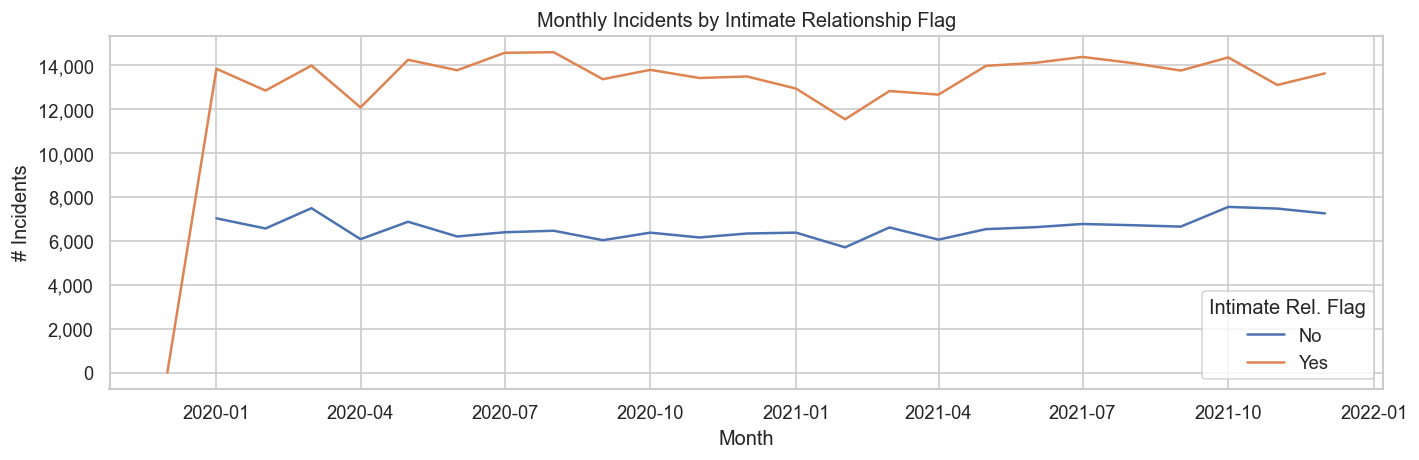

In [25]:
# Separate time series for each value of the intimate relationship flag
# to see if domestic/intimate incidents trend differently over time
irf = impute_copy.copy()
irf['month_year'] = pd.to_datetime(irf['month_year'])
irf_ts = (
    irf.groupby(['month_year', 'Intimate Relationship Flag'])
    .size()
    .reset_index(name='n')
)

fig, ax = plt.subplots(figsize=(12, 4))
for label, grp in irf_ts.groupby('Intimate Relationship Flag'):
    ax.plot(grp['month_year'], grp['n'], label=str(label), linewidth=1.5)

ax.set_title('Monthly Incidents by Intimate Relationship Flag')
ax.set_xlabel('Month')
ax.set_ylabel('# Incidents')
ax.legend(title='Intimate Rel. Flag')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

## 12. Offense Mix: Before vs After Reopening

NameError: name 'pivot2' is not defined

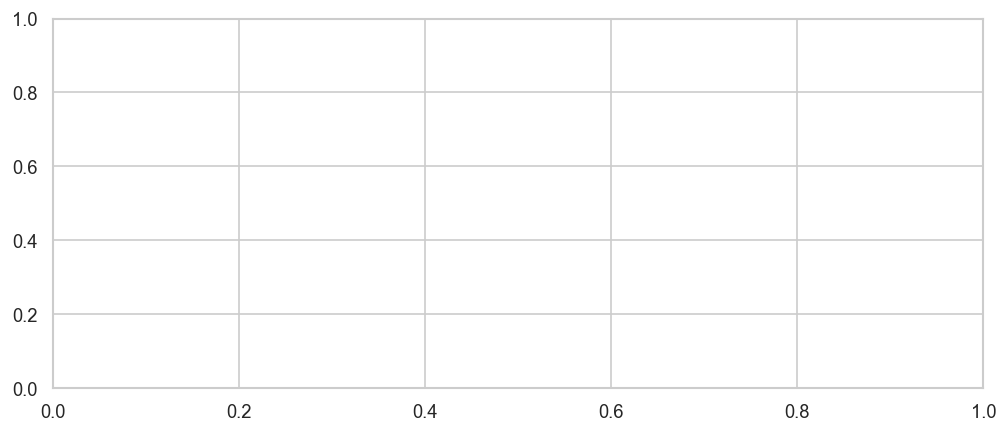

In [26]:
# Define custom colors: light blue for 'Before', purple-blue for 'After'
custom_colors = ['#89CFF0', '#6A5ACD']

fig, ax = plt.subplots(figsize=(10, 4))

# Plot grouped bar chart — each group is an offense type, each bar is a reopening period
pivot2.plot(kind='bar', ax=ax, color=custom_colors)
ax.set_title('Offense Mix: Before vs After Reopening (avg incidents per month)')
ax.set_ylabel('Avg Incidents per Month')
plt.xticks(rotation=30, ha='right')

# Rename legend labels from Yes/No to After/Before for clarity
handles, labels = ax.get_legend_handles_labels()
label_map = {'No': 'Before', 'Yes': 'After'}
new_labels = [label_map.get(l, l) for l in labels]
ax.legend(handles, new_labels, title='After Reopening')

# Annotate each bar with its exact value so small categories like
# Felony Assault and Rape are still readable without squinting
for bar in ax.patches:
    height = bar.get_height()
    if height > 0:  # skip bars with no incidents to avoid clutter
        ax.text(
            bar.get_x() + bar.get_width() / 2,  # horizontally centered on bar
            height + 50,                          # small offset above the bar top
            f'{height:,.0f}',                     # comma-formatted integer
            ha='center', va='bottom', fontsize=8
        )

plt.tight_layout()
plt.show()

In [ ]:
print(offense_reopen.groupby(['after_reopening', 'Offense Type'])['n_per_month'].mean().round(1))

## 13. Export All Plots to PDF

In [ ]:
from matplotlib.backends.backend_pdf import PdfPages
import os

# Save all EDA plots to a single PDF 
save_path = os.path.expanduser('~/Downloads/eda_plots.pdf')

with PdfPages(save_path) as pdf:

    # ── 1. Missingness Bar Chart ──────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(8, 5))
    sns.barplot(data=miss[miss['pct_missing'] > 0], x='pct_missing_pct', y='column', ax=ax, palette='Reds_r')
    ax.set_xlabel('Pct Missing')
    ax.set_ylabel('')
    ax.set_title('Originally Missing Records by Column (raw_copy unknown_* counts)')
    for bar, val in zip(ax.patches, miss[miss['pct_missing'] > 0]['pct_missing_pct']):
        ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2, f'{val}%', va='center', fontsize=9)
    plt.tight_layout()
    pdf.savefig(fig, bbox_inches='tight')
    plt.close()

    # ── 2. Monthly Incident Volume ────────────────────────────────────────────
    ts = impute_copy.copy()
    ts['month_year'] = pd.to_datetime(ts['month_year'])
    monthly = ts.groupby('month_year').size().reset_index(name='n_incidents')
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(monthly['month_year'], monthly['n_incidents'], linewidth=1.5, color='steelblue')
    ax.fill_between(monthly['month_year'], monthly['n_incidents'], alpha=0.15, color='steelblue')
    ax.set_title('Monthly Incident Volume')
    ax.set_xlabel('Month')
    ax.set_ylabel('# Incidents')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    plt.tight_layout()
    pdf.savefig(fig, bbox_inches='tight')
    plt.close()

    # ── 3. Before vs After Reopening (Time Series) ───────────────────────────
    reopen_counts = impute_copy.groupby(['month_year', 'after_reopening']).size().reset_index(name='n')
    reopen_counts['month_year'] = pd.to_datetime(reopen_counts['month_year'])
    fig, ax = plt.subplots(figsize=(12, 4))
    for label, grp in reopen_counts.groupby('after_reopening'):
        ax.plot(grp['month_year'], grp['n'], label=f'after_reopening={label}', linewidth=1.5)
    ax.set_title('Monthly Incidents: Before vs After Reopening')
    ax.set_xlabel('Month')
    ax.set_ylabel('# Incidents')
    ax.legend()
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    plt.tight_layout()
    pdf.savefig(fig, bbox_inches='tight')
    plt.close()

    # ── 4. Offense Type Frequency (Log Scale) ────────────────────────────────
    offense_counts = impute_copy['Offense Type'].value_counts().reset_index()
    offense_counts.columns = ['Offense Type', 'count']
    fig, ax = plt.subplots(figsize=(8, 5))
    sns.barplot(data=offense_counts, x='count', y='Offense Type', palette='Blues_r', ax=ax)
    ax.set_xscale('log')
    ax.set_title('Offense Type Frequency (imputed) — log scale')
    ax.set_xlabel('Count (log scale)')
    ax.set_ylabel('')
    for bar, val in zip(ax.patches, offense_counts['count']):
        ax.text(bar.get_width() * 1.05, bar.get_y() + bar.get_height()/2, f'{int(val):,}', va='center', fontsize=9)
    plt.tight_layout()
    pdf.savefig(fig, bbox_inches='tight')
    plt.close()

    # ── 5. Incidents by Borough ───────────────────────────────────────────────
    borough_counts = impute_copy['Borough Name'].value_counts().reset_index()
    borough_counts.columns = ['Borough Name', 'count']
    fig, ax = plt.subplots(figsize=(7, 4))
    sns.barplot(data=borough_counts, x='Borough Name', y='count', ax=ax)
    ax.set_title('Incidents by Borough (imputed)')
    ax.set_ylabel('Count')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    plt.tight_layout()
    pdf.savefig(fig, bbox_inches='tight')
    plt.close()

    # ── 6. Categorical Variables: Imputed vs Raw (one page per column) ────────
    cat_cols = ['Victim Race', 'Victim Sex', 'Suspect Race', 'Suspect Sex', 'Intimate Relationship Flag']
    for col in cat_cols:
        imp_vc = impute_copy[col].value_counts(normalize=True).rename('Imputed')
        raw_vc = raw_copy[col].value_counts(normalize=True).rename('Raw')
        combined = pd.concat([imp_vc, raw_vc], axis=1).fillna(0).sort_values('Imputed', ascending=False)
        combined.index = [re.sub(r'^unknown_.*', 'Unknown', str(i)) for i in combined.index]
        fig, ax_inner = plt.subplots(figsize=(10, 3))
        combined.plot(kind='bar', ax=ax_inner, color=['#89CFF0', '#6A5ACD'])
        ax_inner.set_title(f'{col}: Imputed vs Raw Proportions')
        ax_inner.set_ylabel('Proportion')
        plt.xticks(rotation=30, ha='right')
        ax_inner.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), frameon=True)
        plt.tight_layout()
        pdf.savefig(fig, bbox_inches='tight')
        plt.close()

    # ── 7. COMMDIST Histogram ─────────────────────────────────────────────────
    socio_encoded = impute_copy[['Unemployment', 'Median Income', 'Poverty', 'COMMDIST']].copy()
    for col in ['Unemployment', 'Median Income', 'Poverty']:
        socio_encoded[col] = socio_encoded[col].map({'Yes': 1, 'No': 0})
    socio_encoded['COMMDIST'] = pd.to_numeric(socio_encoded['COMMDIST'], errors='coerce')
    fig, ax = plt.subplots(figsize=(6, 4))
    socio_encoded['COMMDIST'].hist(bins=40, ax=ax, color='steelblue', edgecolor='white')
    ax.set_title('COMMDIST Distribution')
    ax.set_ylabel('Count')
    ax.set_xlabel('COMMDIST')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    plt.tight_layout()
    pdf.savefig(fig, bbox_inches='tight')
    plt.close()

    # ── 8. Socioeconomic Flag Stacked Bars ────────────────────────────────────
    flag_cols = ['Unemployment', 'Median Income', 'Poverty']
    fig, axes = plt.subplots(1, 3, figsize=(10, 4))
    for ax, col in zip(axes, flag_cols):
        counts = impute_copy[col].value_counts(normalize=True) * 100
        ax.bar(col, counts.get('Yes', 0), color='steelblue', label='Yes')
        ax.bar(col, counts.get('No', 0), bottom=counts.get('Yes', 0), color='lightcoral', label='No')
        ax.set_title(col)
        ax.set_ylabel('% of Incidents')
        ax.set_ylim(0, 100)
        ax.set_xticks([])
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
        ax.text(col, counts.get('Yes', 0) / 2, f"Yes\n{counts.get('Yes', 0):.1f}%", ha='center', va='center', color='white', fontsize=10)
        ax.text(col, counts.get('Yes', 0) + counts.get('No', 0) / 2, f"No\n{counts.get('No', 0):.1f}%", ha='center', va='center', color='white', fontsize=10)
    plt.suptitle('Socioeconomic Flag Distributions', y=1.02)
    plt.tight_layout()
    pdf.savefig(fig, bbox_inches='tight')
    plt.close()

    # ── 9. Socioeconomic Correlation Matrix ───────────────────────────────────
    corr = socio_encoded.corr()
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='YlOrRd', center=0, ax=ax, square=True)
    ax.set_title('Correlation Matrix — Socioeconomic Covariates')
    plt.tight_layout()
    pdf.savefig(fig, bbox_inches='tight')
    plt.close()

    # ── 10. Borough x Offense Type Heatmap ───────────────────────────────────
    pivot = (
        impute_copy
        .groupby(['Borough Name', 'Offense Type'])
        .size()
        .reset_index(name='count')
        .pivot(index='Borough Name', columns='Offense Type', values='count')
        .fillna(0)
    )
    fig, ax = plt.subplots(figsize=(10, 4))
    sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd', ax=ax, linewidths=0.5)
    ax.set_title('Incident Count: Borough x Offense Type')
    plt.xticks(rotation=25, ha='right')
    plt.tight_layout()
    pdf.savefig(fig, bbox_inches='tight')
    plt.close()

    # ── 11. Monthly Incidents by Intimate Relationship Flag ───────────────────
    irf = impute_copy.copy()
    irf['month_year'] = pd.to_datetime(irf['month_year'])
    irf_ts = irf.groupby(['month_year', 'Intimate Relationship Flag']).size().reset_index(name='n')
    fig, ax = plt.subplots(figsize=(12, 4))
    for label, grp in irf_ts.groupby('Intimate Relationship Flag'):
        ax.plot(grp['month_year'], grp['n'], label=str(label), linewidth=1.5)
    ax.set_title('Monthly Incidents by Intimate Relationship Flag')
    ax.set_xlabel('Month')
    ax.set_ylabel('# Incidents')
    ax.legend(title='Intimate Rel. Flag')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    plt.tight_layout()
    pdf.savefig(fig, bbox_inches='tight')
    plt.close()

    # ── 12. Offense Mix: Before vs After Reopening ────────────────────────────
    fig, ax = plt.subplots(figsize=(10, 4))
    pivot2.plot(kind='bar', ax=ax, color=['#89CFF0', '#6A5ACD'])
    ax.set_title('Offense Mix: Before vs After Reopening (avg incidents per month)')
    ax.set_ylabel('Avg Incidents per Month')
    plt.xticks(rotation=30, ha='right')
    handles, labels = ax.get_legend_handles_labels()
    label_map = {'No': 'Before', 'Yes': 'After'}
    new_labels = [label_map.get(l, l) for l in labels]
    ax.legend(handles, new_labels, title='After Reopening')
    for bar in ax.patches:
        height = bar.get_height()
        if height > 0:
            ax.text(bar.get_x() + bar.get_width() / 2, height + 50, f'{height:,.0f}', ha='center', va='bottom', fontsize=8)
    plt.tight_layout()
    pdf.savefig(fig, bbox_inches='tight')
    plt.close()

print(f'All 12 plots saved to: {save_path}')
